# Exploratory Data Analysis (EDA) for Ride Cancellation

**Author:** Zehra Buse Tüfekçi  
**Date:** 02 March 2026  

## Purpose of This Notebook
In this notebook, we explore the processed ride-hailing dataset to understand the data distributions, relationships between features, and patterns related to ride cancellations.

## Data Loading
We load the processed dataset generated from the Feature Engineering notebook.

In [ ]:
from google.colab import files
files.upload()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ride_cancellation_processed_v1.csv")
# Preview first few rows
df.head()

,Booking Status,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
0,Completed,13.4,25.8,0.0,0.0,627.0,13.58,4.9,4.9,1,...,0,0,2024,8,23,4,0,8,56,0
1,Completed,13.1,28.5,0.0,0.0,416.0,34.02,4.6,5.0,0,...,1,0,2024,10,21,0,0,17,17,0
2,Completed,5.3,19.6,0.0,0.0,737.0,48.21,4.1,4.3,0,...,1,0,2024,9,16,0,0,22,8,0
3,Completed,5.1,18.1,0.0,0.0,316.0,4.85,4.1,4.6,1,...,1,0,2024,2,6,1,0,9,44,0
4,Completed,7.1,20.4,0.0,0.0,640.0,41.24,4.0,4.1,0,...,1,0,2024,6,17,0,0,15,45,0


In [4]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130500 entries, 0 to 130499
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Booking Status               130500 non-null  object 
 1   Avg VTAT                     130500 non-null  float64
 2   Avg CTAT                     130500 non-null  float64
 3   Cancelled Rides by Customer  130500 non-null  float64
 4   Cancelled Rides by Driver    130500 non-null  float64
 5   Booking Value                130500 non-null  float64
 6   Ride Distance                130500 non-null  float64
 7   Driver Ratings               130500 non-null  float64
 8   Customer Rating              130500 non-null  float64
 9   Vehicle Type_Auto            130500 non-null  int64  
 10  Vehicle Type_Bike            130500 non-null  int64  
 11  Vehicle Type_Go Mini         130500 non-null  int64  
 12  Vehicle Type_Go Sedan        130500 non-null  int64  
 13 

In [5]:
# Columns and shape
df.columns

Index(['Booking Status', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer',
       'Cancelled Rides by Driver', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Vehicle Type_Auto',
       'Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan',
       'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL',
       'Vehicle Type_eBike', 'Payment Method_Cash',
       'Payment Method_Credit Card', 'Payment Method_Debit Card',
       'Payment Method_UPI', 'Payment Method_Uber Wallet', 'Year', 'Month',
       'Day', 'Day_of_week', 'Is_weekend', 'Hour', 'Minute', 'target'],
      dtype='object')

In [6]:
df.shape

(130500, 29)

##Check for missing values

Missing values can affect analysis and modeling. We check which columns have missing data and their percentages.

In [7]:
# Missing values by column
df.isnull().sum()

,0
Booking Status,0
Avg VTAT,0
Avg CTAT,0
Cancelled Rides by Customer,0
Cancelled Rides by Driver,0
Booking Value,0
Ride Distance,0
Driver Ratings,0
Customer Rating,0
Vehicle Type_Auto,0


In [8]:
# Percentage of missing values
df.isnull().mean() * 100

,0
Booking Status,0.0
Avg VTAT,0.0
Avg CTAT,0.0
Cancelled Rides by Customer,0.0
Cancelled Rides by Driver,0.0
Booking Value,0.0
Ride Distance,0.0
Driver Ratings,0.0
Customer Rating,0.0
Vehicle Type_Auto,0.0


##Basic statistics

We explore basic statistics for numerical and categorical columns to get a quick overview of the dataset.

In [9]:
# Statistics for numerical columns
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Vehicle Type_Auto,Vehicle Type_Bike,...,Payment Method_UPI,Payment Method_Uber Wallet,Year,Month,Day,Day_of_week,Is_weekend,Hour,Minute,target
count,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,...,130500.000000,130500.000000,130500.0,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000,130500.000000
mean,8.624808,29.679952,0.080460,0.206897,481.115510,25.345179,4.250822,4.432002,0.248874,0.150851,...,0.607923,0.085870,2024.0,6.488667,15.643962,2.998222,0.286797,14.034345,29.460268,0.287356
std,3.796752,7.324108,0.272005,0.405082,337.050588,11.715647,0.370118,0.372112,0.432362,0.357905,...,0.488215,0.280173,0.0,3.444554,8.783080,2.004343,0.452268,5.418976,17.318205,0.452531
min,2.000000,15.000000,0.000000,0.000000,50.000000,2.000000,3.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.500000,25.600000,0.000000,0.000000,308.000000,18.880000,4.200000,4.300000,0.000000,0.000000,...,0.000000,0.000000,2024.0,3.000000,8.000000,1.000000,0.000000,10.000000,15.000000,0.000000
50%,8.500000,28.800000,0.000000,0.000000,414.000000,23.720000,4.300000,4.500000,0.000000,0.000000,...,1.000000,0.000000,2024.0,6.000000,16.000000,3.000000,0.000000,15.000000,29.000000,0.000000
75%,11.500000,34.500000,0.000000,0.000000,544.000000,33.110000,4.400000,4.600000,0.000000,0.000000,...,1.000000,0.000000,2024.0,9.000000,23.000000,5.000000,1.000000,18.000000,44.000000,1.000000
max,20.000000,45.000000,1.000000,1.000000,4277.000000,50.000000,5.000000,5.000000,1.000000,1.000000,...,1.000000,1.000000,2024.0,12.000000,31.000000,6.000000,1.000000,23.000000,59.000000,1.000000


In [10]:
# Statistics for categorical columns
df.describe(include=['object', 'category'])

,Booking Status
count,130500
unique,3
top,Completed
freq,93000


##Analyze the Features with the Target

This step involves examining how each feature in the dataset relates to the target variable. The goal is to understand which features are most influential for predicting the target and how they interact with it.

In [11]:
df['target'].value_counts()

,count
target,
0,93000
1,37500


In [12]:
# Percentage distribution
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.712644
1,0.287356


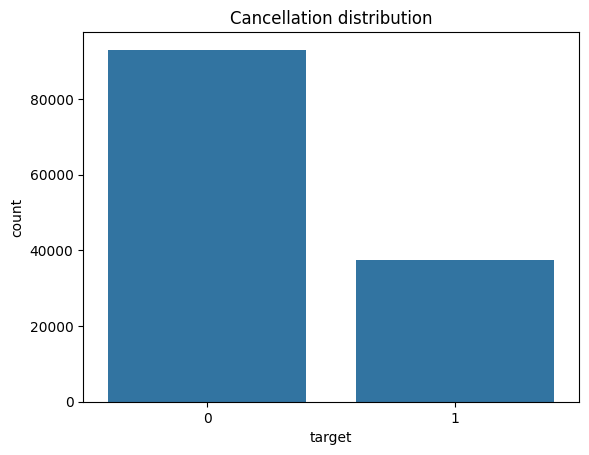

In [13]:
# Visualization
sns.countplot(x='target', data=df)
plt.title('Cancellation distribution')
plt.show()

##Exploratory analysis of numerical features

We explore the distribution of numerical columns using histograms and boxplots to check for outliers and basic patterns.

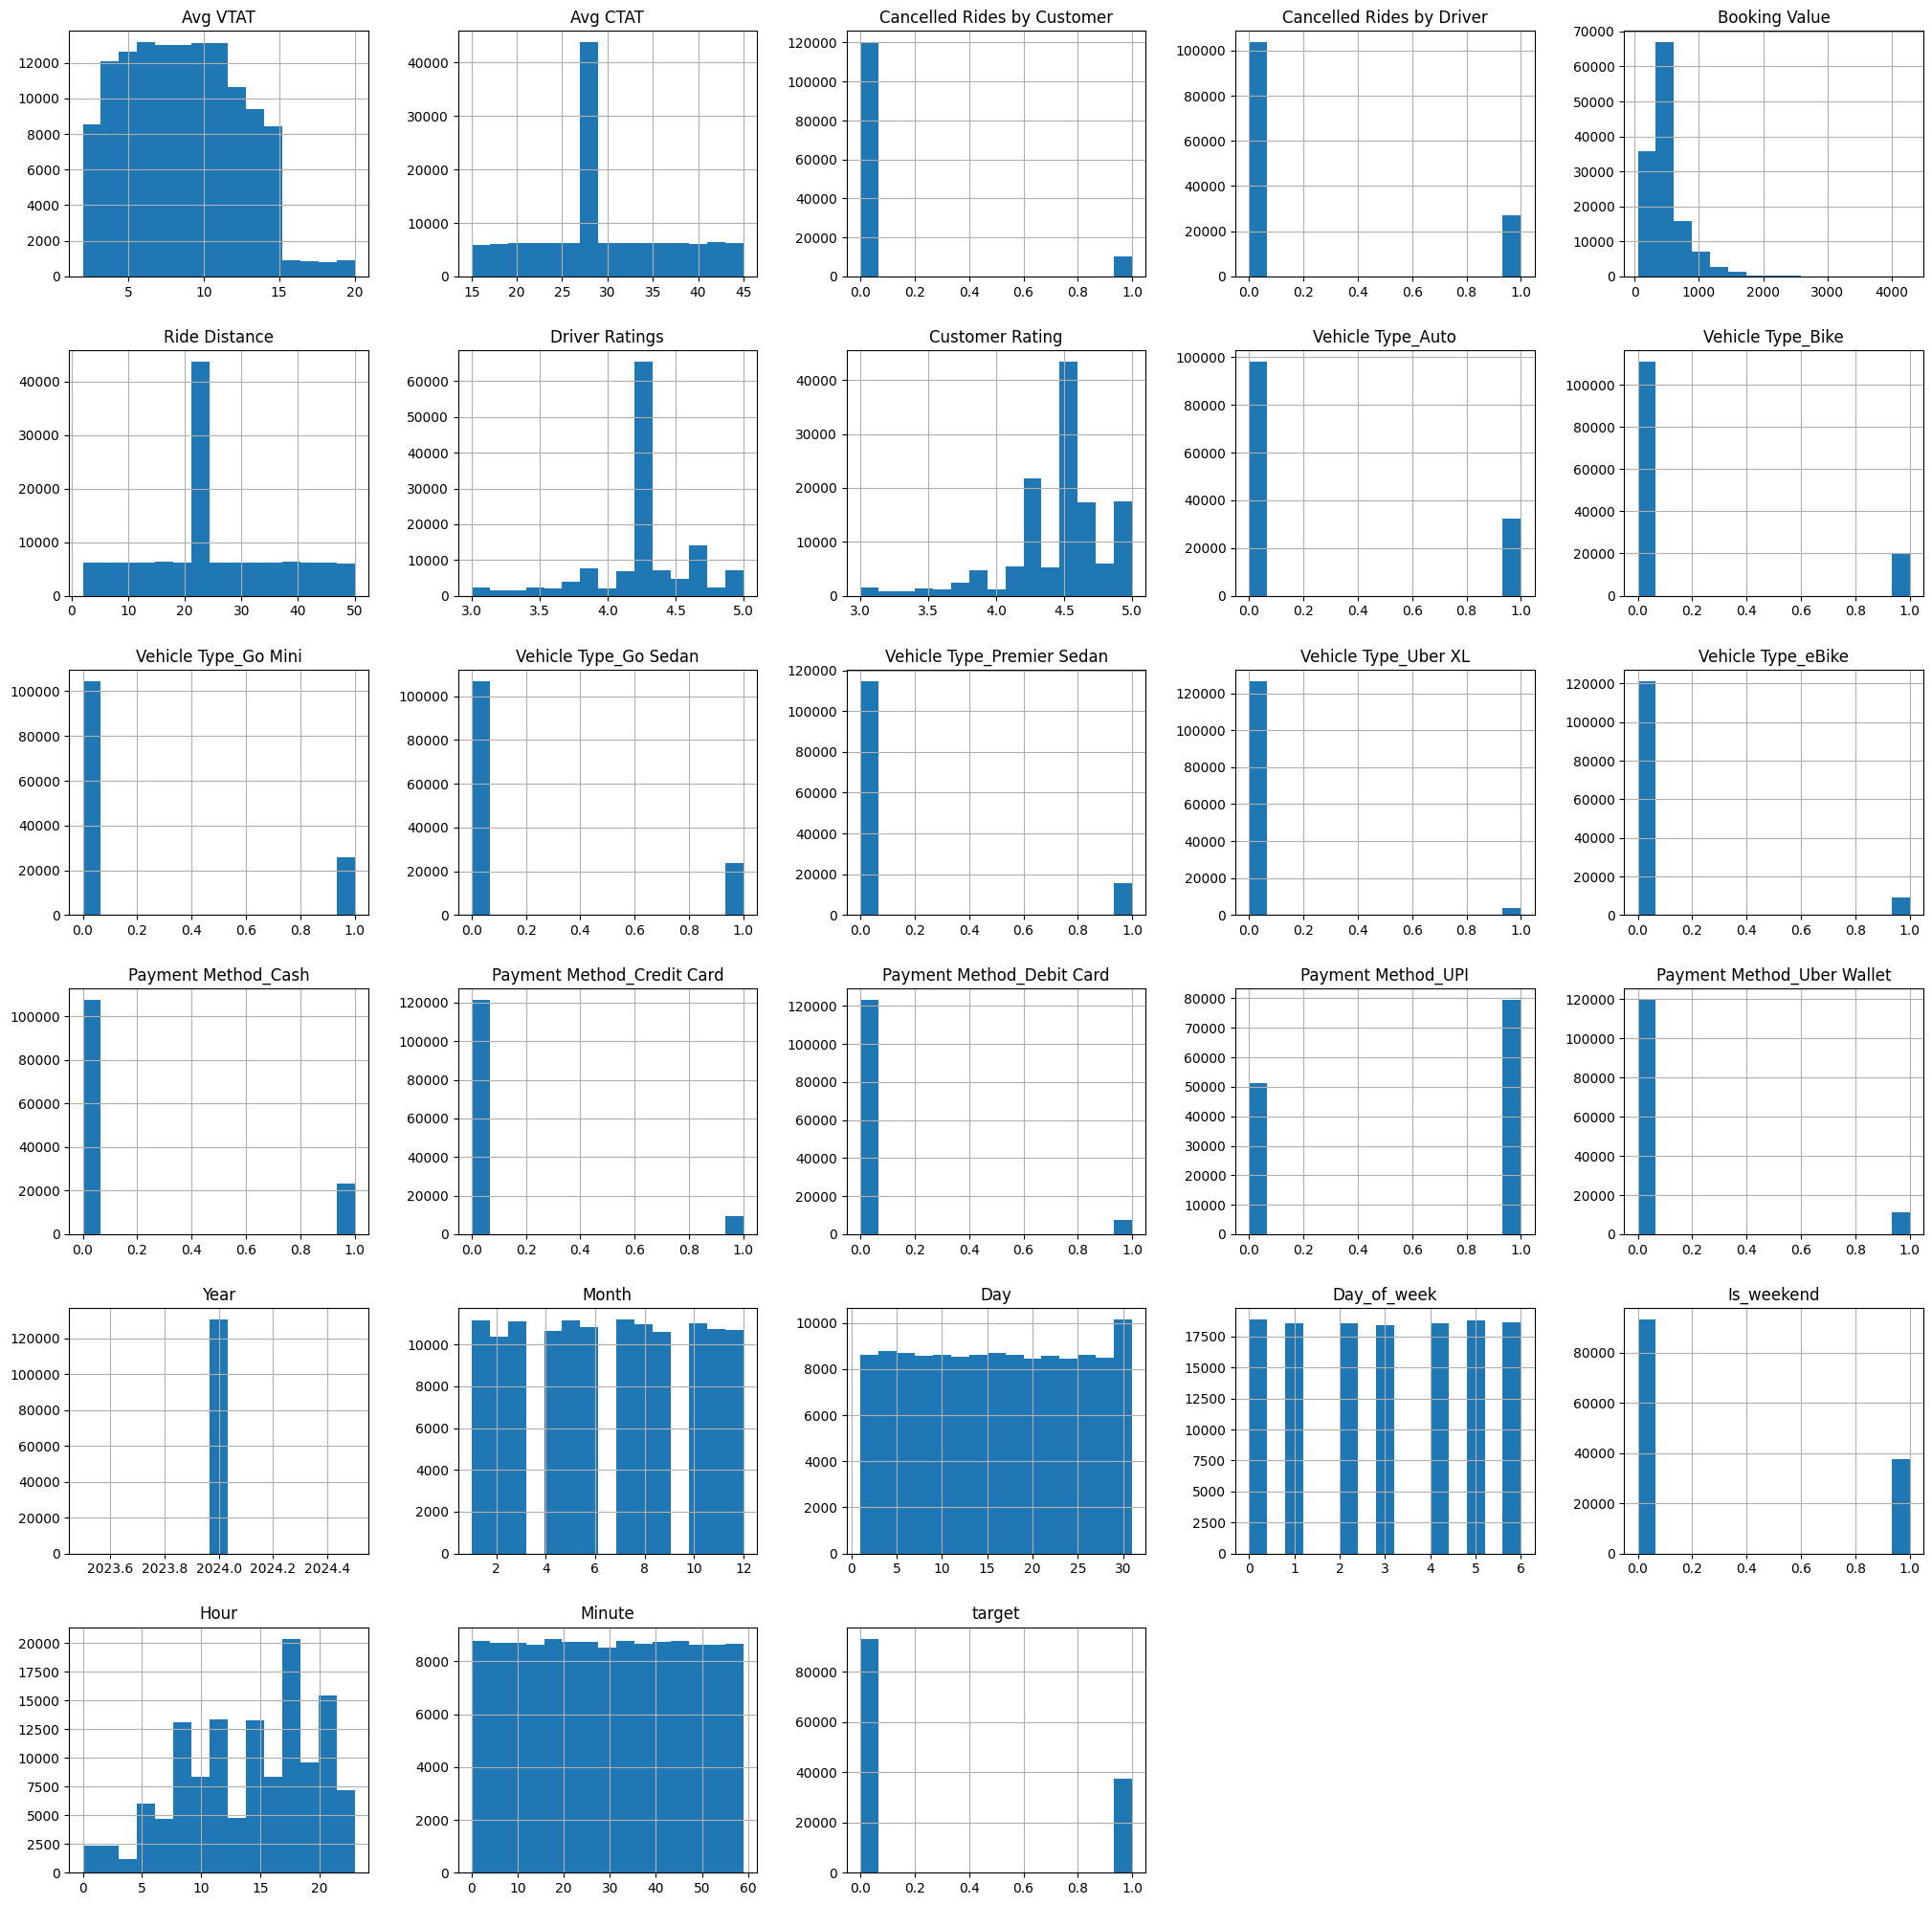

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Histograms
df[numerical_cols].hist(bins=15, figsize=(25,25))
plt.show()


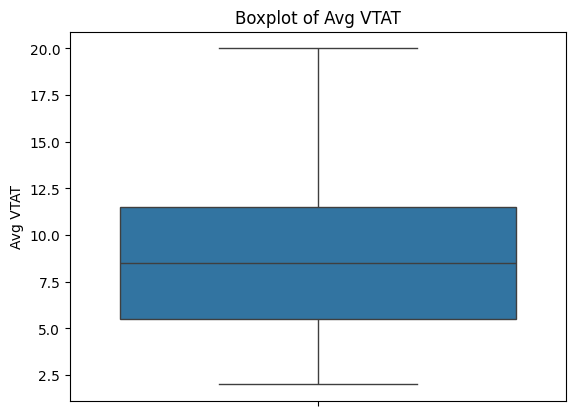

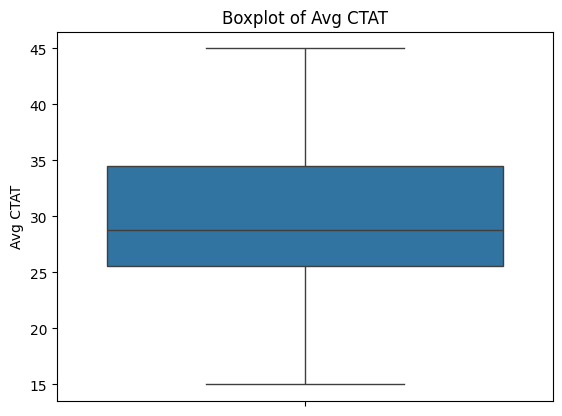

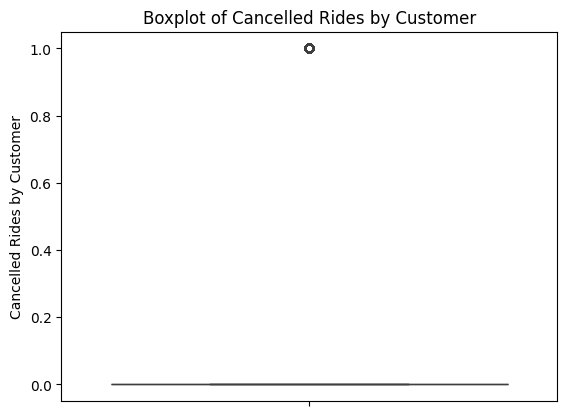

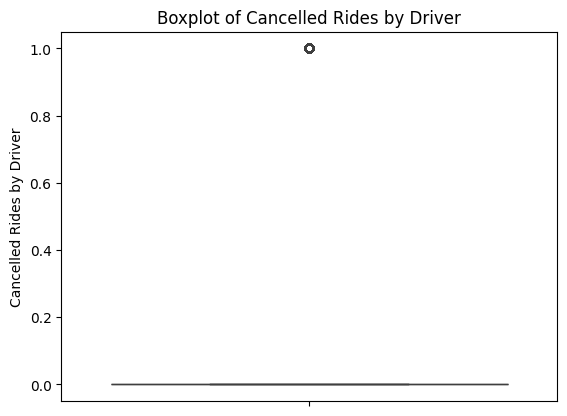

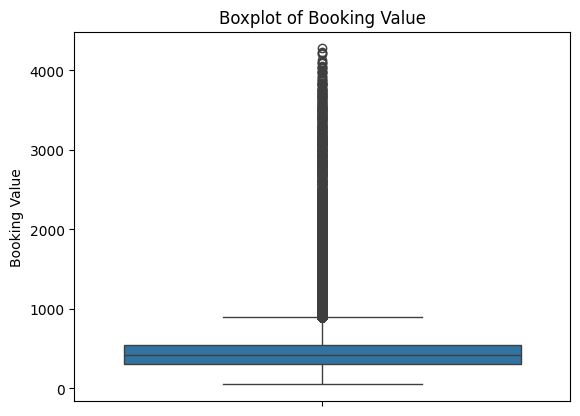

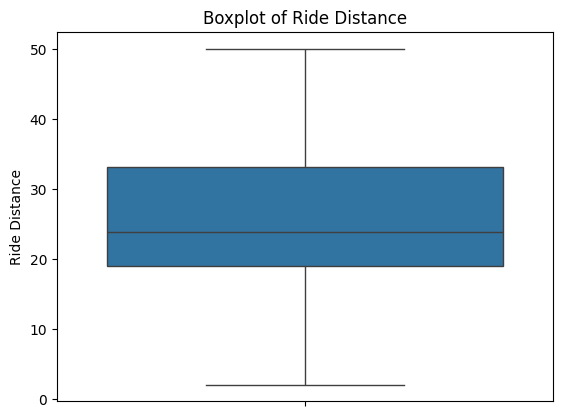

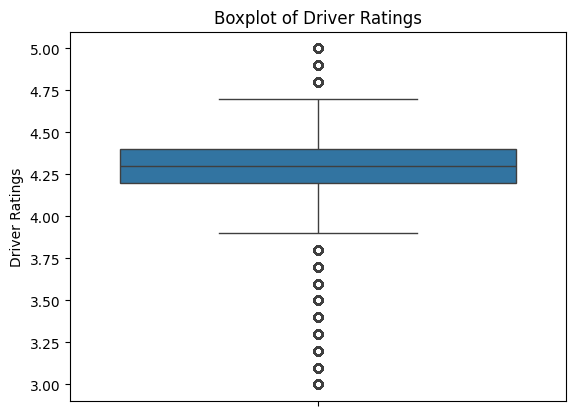

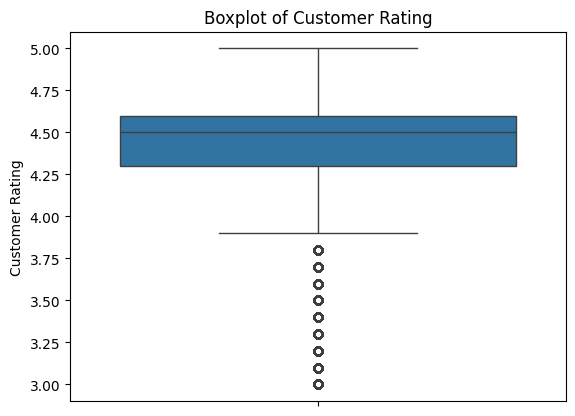

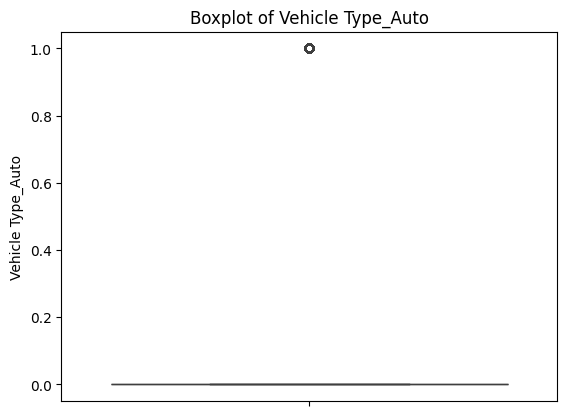

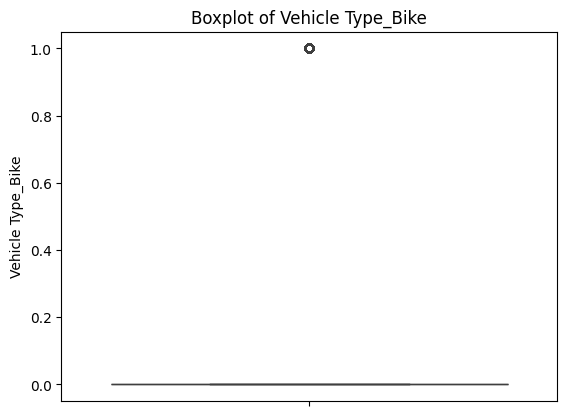

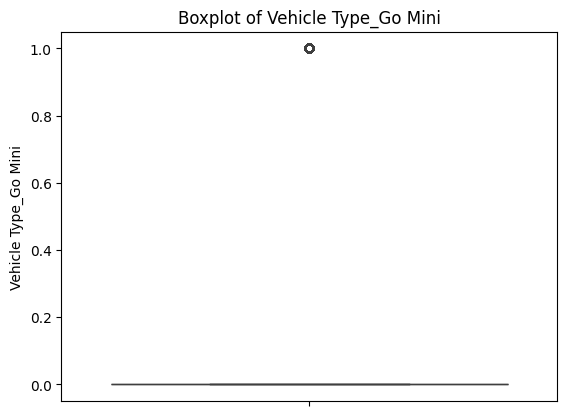

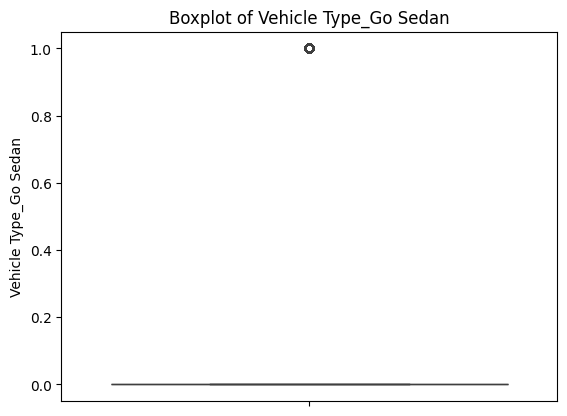

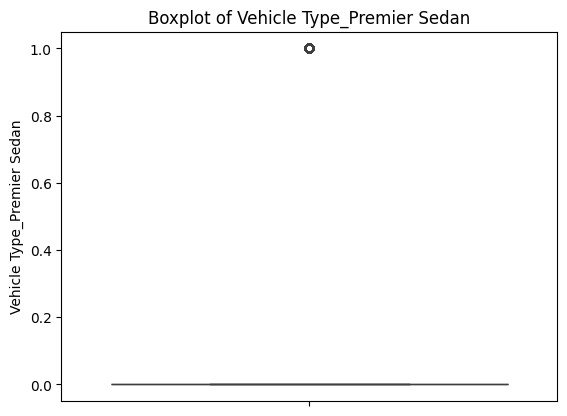

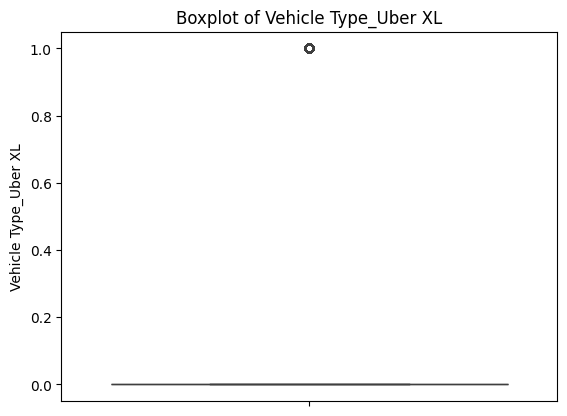

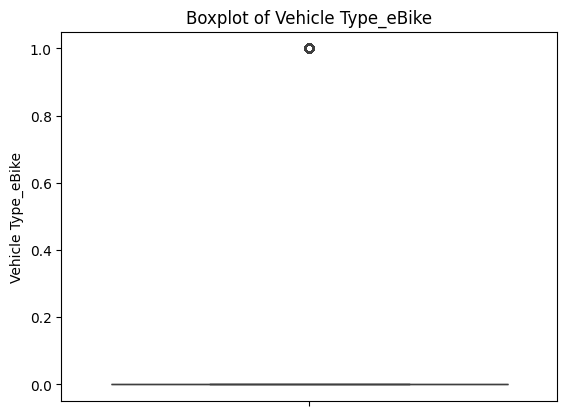

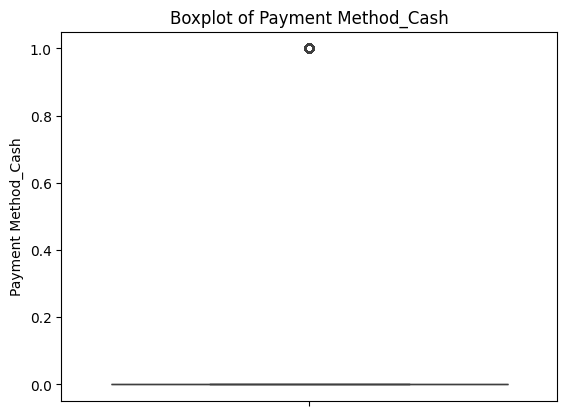

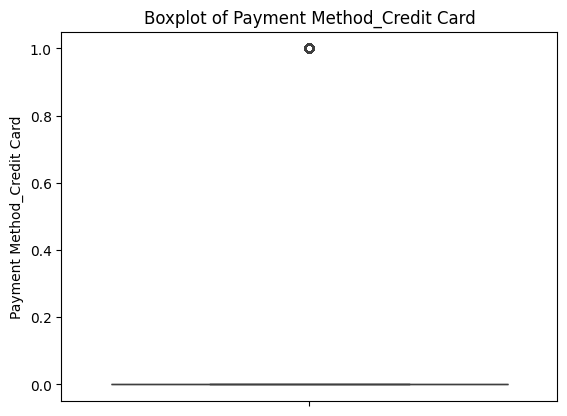

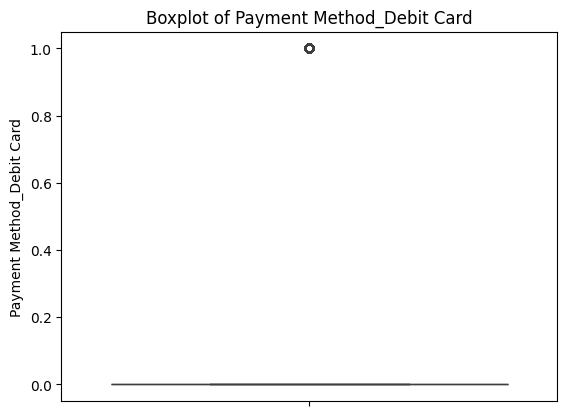

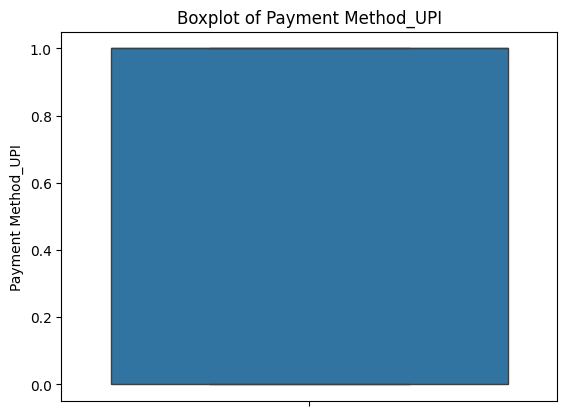

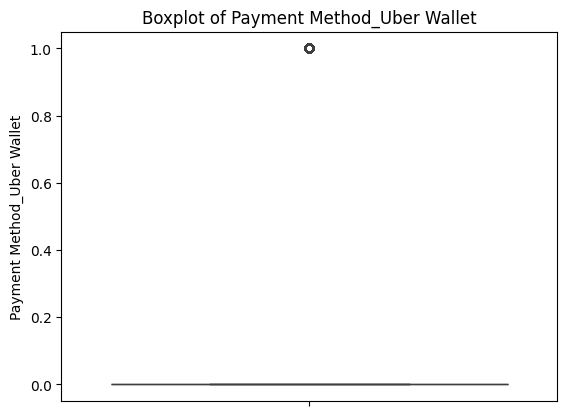

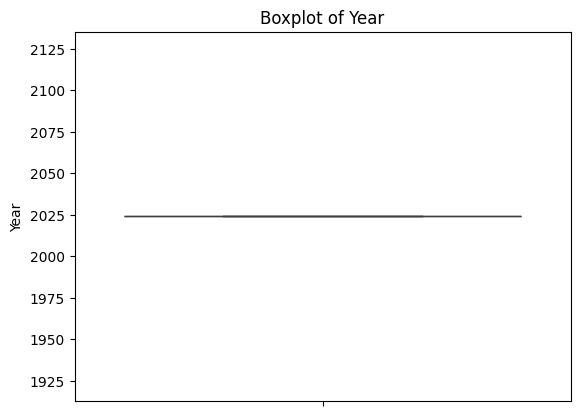

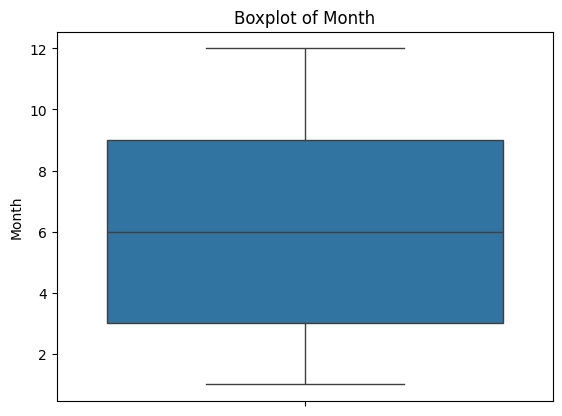

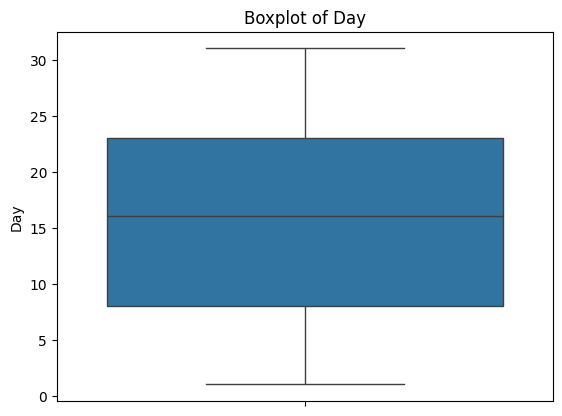

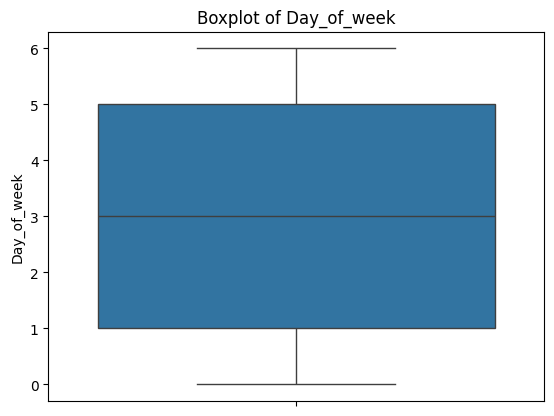

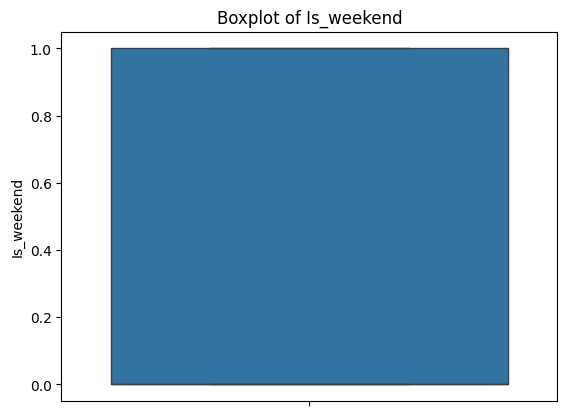

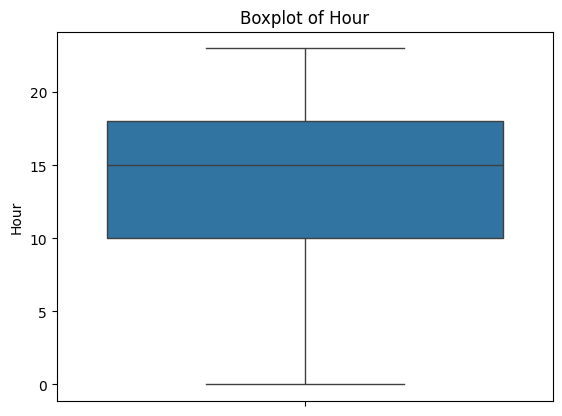

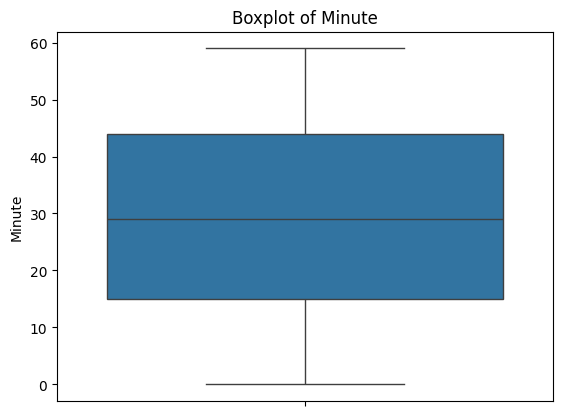

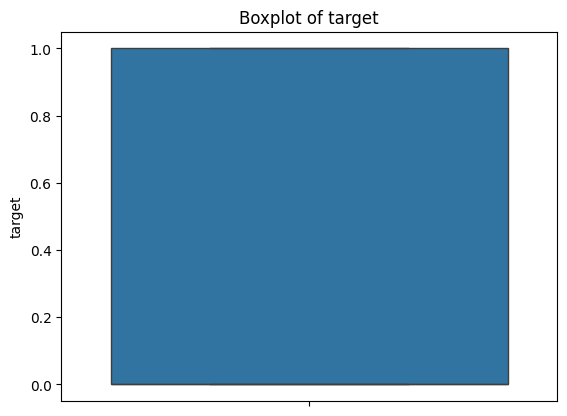

In [15]:
# Boxplots
for col in numerical_cols:
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

##Exploratory analysis of categorical features

We examine categorical columns to understand the distribution of categories and how they relate to cancellations.

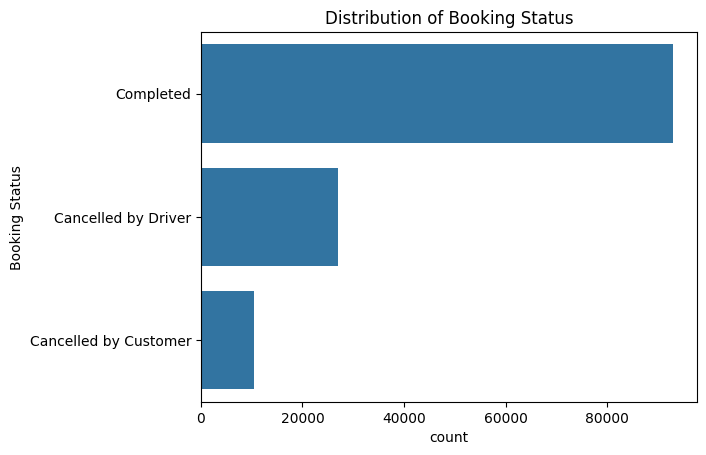

In [16]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

## Cancellation Analysis by Time of Day

This section analyzes ride cancellations throughout the day. We explore:
- Hourly cancellation counts
- Hourly cancellation rates
- Specific hour:minute cancellation hotspots
- 15-minute interval cancellation patterns

These insights help identify peak cancellation periods and improve operational planning.

In [22]:
cancel_by_hour = (
    df[df['target'] == 1]
    .groupby('Hour')
    .size()
    .reset_index(name='cancel_count')
    .sort_values(by='cancel_count', ascending=False)
    .reset_index(drop=True)
)

cancel_by_hour

,Hour,cancel_count
0,18,3146
1,19,2820
2,17,2749
3,10,2385
4,20,2368
5,16,2362
6,15,2106
7,9,2051
8,11,2018
9,21,1943


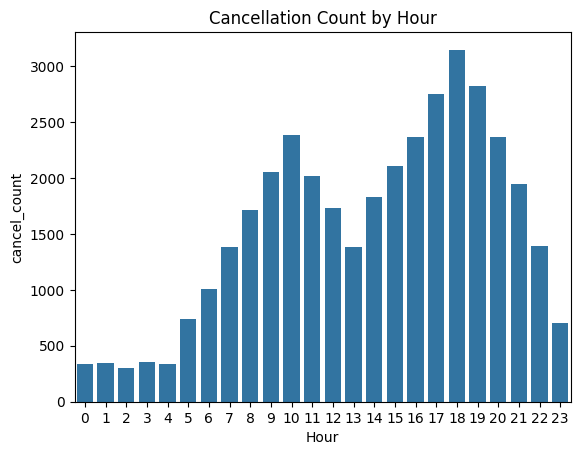

In [21]:
sns.barplot(x='Hour', y='cancel_count', data=cancel_by_hour)
plt.title('Cancellation Count by Hour')
plt.show()

In [24]:
hourly_stats = (
    df.groupby('Hour')['target']
    .agg(
        total_bookings='count',
        cancel_count='sum'
    )
    .reset_index()
)

hourly_stats['cancel_rate'] = (
    hourly_stats['cancel_count'] / hourly_stats['total_bookings']
)

hourly_stats.sort_values(by='cancel_rate', ascending=False)

,Hour,total_bookings,cancel_count,cancel_rate
5,5,2451,736,0.300286
14,14,6144,1834,0.298503
15,15,7163,2106,0.294011
1,1,1172,344,0.293515
22,22,4742,1391,0.293336
19,19,9618,2820,0.293200
7,7,4728,1382,0.292301
18,18,10763,3146,0.292298
3,3,1215,355,0.292181
13,13,4757,1381,0.290309


In [28]:
df['booking_time'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
df['hour_minute'] = df['booking_time'].dt.strftime('%H:%M')

cancel_by_hour_min = (
    df[df['target'] == 1]
    .groupby('hour_minute')
    .size()
    .reset_index(name='cancel_count')
    .sort_values(by='cancel_count', ascending=False)
)

cancel_by_hour_min.head(10)

,hour_minute,cancel_count
1092,18:13,67
1119,18:40,66
1126,18:47,66
1132,18:53,65
1122,18:43,65
1131,18:52,65
1113,18:34,63
1216,20:17,63
1152,19:13,62
1094,18:15,62


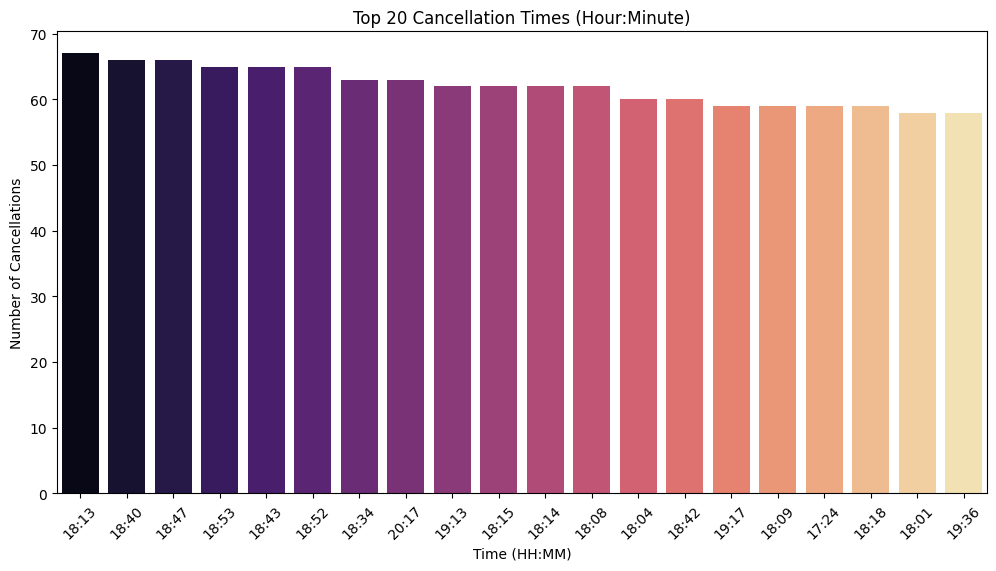

In [35]:
plt.figure(figsize=(12,6))
top20 = cancel_by_hour_min.head(20)
sns.barplot(x='hour_minute', y='cancel_count', data=top20, palette='magma', hue='hour_minute', legend=False)
plt.xticks(rotation=45)
plt.title('Top 20 Cancellation Times (Hour:Minute)')
plt.xlabel('Time (HH:MM)')
plt.ylabel('Number of Cancellations')
plt.show()

In [31]:
df['time_15min'] = df['booking_time'].dt.floor('15min').dt.strftime('%H:%M')

cancel_15min = (
    df[df['target'] == 1]
    .groupby('time_15min')
    .size()
    .reset_index(name='cancel_count')
    .sort_values(by='cancel_count', ascending=False)
)

cancel_15min.head(10)

,time_15min,cancel_count
75,18:45,802
72,18:00,801
74,18:30,772
73,18:15,771
78,19:30,726
70,17:30,720
77,19:15,710
76,19:00,701
68,17:00,683
79,19:45,683


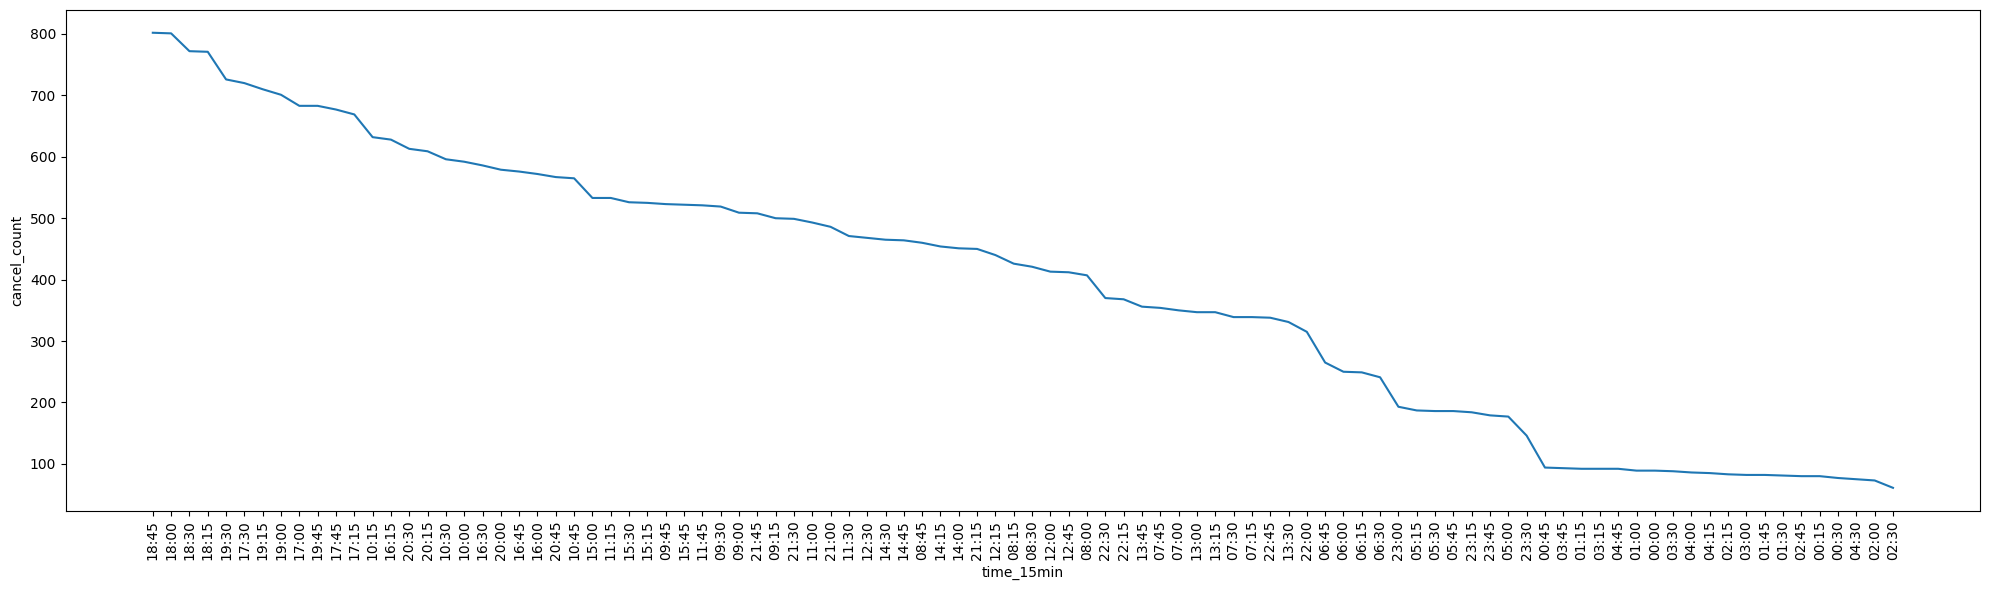

In [38]:
plt.figure(figsize=(20,6))
sns.lineplot(x='time_15min', y='cancel_count', data=cancel_15min)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Day-wise Cancellation Analysis

This section explores cancellations by day to understand patterns in booking behavior. The goal is to identify:

1. **Which day of the month has the most cancellations** – this helps detect if certain dates are prone to cancellations.
2. **Which day of the week has the highest cancellation counts** – this reveals weekly patterns, e.g., whether cancellations are more common on weekdays or weekends.

In [61]:
cancel_by_month = (
    df[df['target'] == 1]
    .groupby('Month')
    .size()
    .reset_index(name='cancel_count')
    .sort_values(by='cancel_count', ascending=False)
)
print(cancel_by_month)

    Month  cancel_count
6       7          3264
4       5          3236
0       1          3217
7       8          3185
2       3          3146
9      10          3118
5       6          3089
10     11          3084
11     12          3074
8       9          3059
1       2          3028
3       4          3000


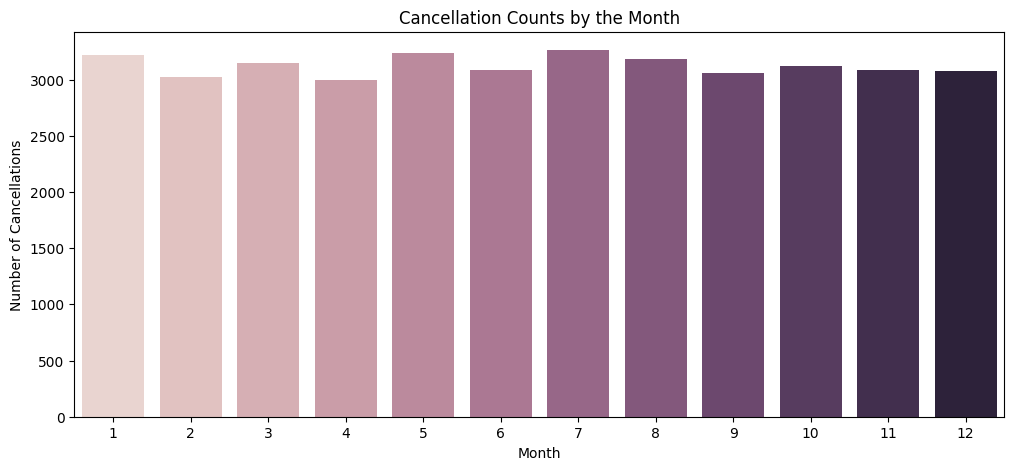

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.barplot(
    x='Month',
    y='cancel_count',
    hue='Month',
    data=cancel_by_month,
    dodge=False
)
plt.title('Cancellation Counts by the Month')
plt.xlabel('Month')
plt.ylabel('Number of Cancellations')
plt.legend().remove()
plt.show()

In [63]:
cancel_by_year = (
    df[df['target'] == 1]
    .groupby('Year')
    .size()
    .reset_index(name='cancel_count')
    .sort_values(by='cancel_count', ascending=False)
)
print(cancel_by_year)

   Year  cancel_count
0  2024         37500


In [54]:
df['day_of_week'] = df['booking_date'].dt.day_name()  # Monday, Tuesday, ...

cancel_by_weekday = (
    df[df['target'] == 1]
    .groupby('day_of_week')
    .size()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index(name='cancel_count')
)
print(cancel_by_weekday)

  day_of_week  cancel_count
0      Monday          5552
1     Tuesday          5388
2   Wednesday          5315
3    Thursday          5231
4      Friday          5343
5    Saturday          5328
6      Sunday          5343


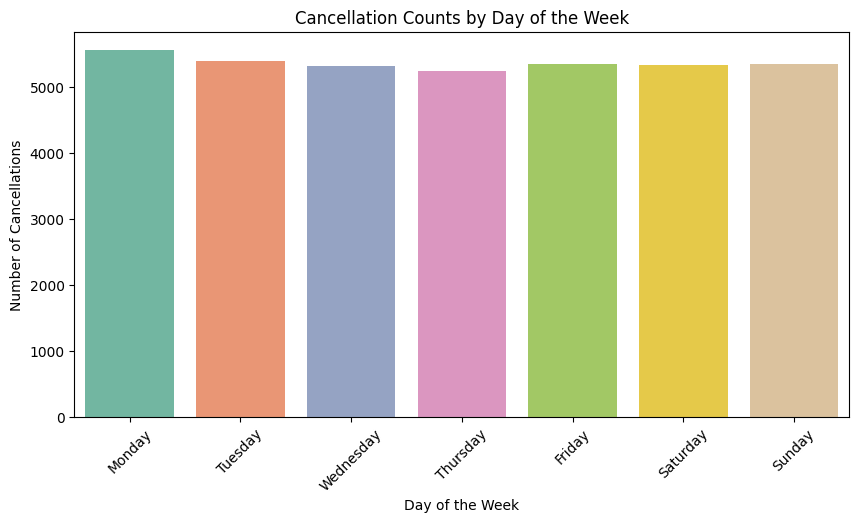

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    x='day_of_week',
    y='cancel_count',
    data=cancel_by_weekday,
    hue='day_of_week',
    palette='Set2',
    dodge=False
)
plt.title('Cancellation Counts by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)
plt.show()

In [69]:
df['week_part'] = df['booking_date'].dt.weekday.apply(lambda x: 'Weekday' if x < 5 else 'Weekend')

cancel_by_week_part = (
    df[df['target'] == 1]
    .groupby('week_part')
    .size()
    .reset_index(name='cancel_count')
)
print(cancel_by_week_part)

  week_part  cancel_count
0   Weekday         26829
1   Weekend         10671


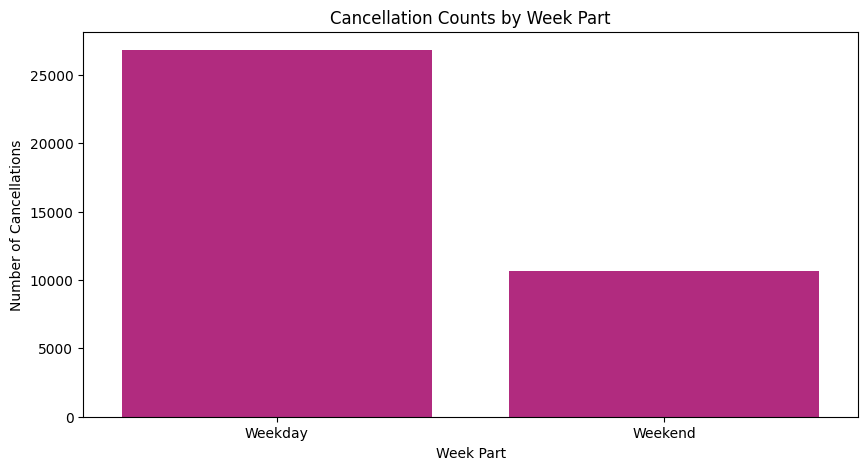

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    x='week_part',
    y='cancel_count',
    data=cancel_by_week_part,
    color='mediumvioletred'
)
plt.title('Cancellation Counts by Week Part')
plt.xlabel('Week Part')
plt.ylabel('Number of Cancellations')
plt.show()

## Vehicle Type & Payment Method Cancellation Analysis

This section explores how **vehicle types** and **payment methods** relate to cancellations.  
Since these features were **one-hot encoded**, we analyze the cancellation patterns by first transforming them back into a **long format** to get meaningful statistics.

Key steps:

1. **Vehicle Type Analysis**
   - Transform one-hot encoded vehicle type columns into long format.
   - Filter for the relevant vehicle in each row (where value = 1).
   - Calculate **cancellation rate** per vehicle type.
   - Visualize the results using a bar plot to see which vehicle types have higher cancellation likelihood.

2. **Payment Method Analysis**
   - Similarly, transform one-hot encoded payment method columns into long format.
   - Filter for the relevant payment method in each row (where value = 1).
   - Calculate **cancellation rate** per payment method.
   - Visualize the results using a bar plot to compare cancellation patterns across payment methods.

**Insights:**
- Helps identify which vehicle types or payment methods are associated with higher cancellation risk.
- This can be used for operational improvements, risk prediction, or dynamic interventions.

In [74]:
vehicle_cols = [col for col in df.columns if 'Vehicle Type' in col]


df_vehicle = df.melt(id_vars='target', value_vars=vehicle_cols,
                     var_name='vehicle_type', value_name='is_type')


df_vehicle = df_vehicle[df_vehicle['is_type'] == 1]


vehicle_cancel_rate = df_vehicle.groupby('vehicle_type')['target'].mean().sort_values(ascending=False)
print(vehicle_cancel_rate)

vehicle_type
Vehicle Type_Go Sedan         0.291559
Vehicle Type_Bike             0.287108
Vehicle Type_Auto             0.287056
Vehicle Type_eBike            0.286461
Vehicle Type_Premier Sedan    0.286403
Vehicle Type_Go Mini          0.285918
Vehicle Type_Uber XL          0.281250
Name: target, dtype: float64


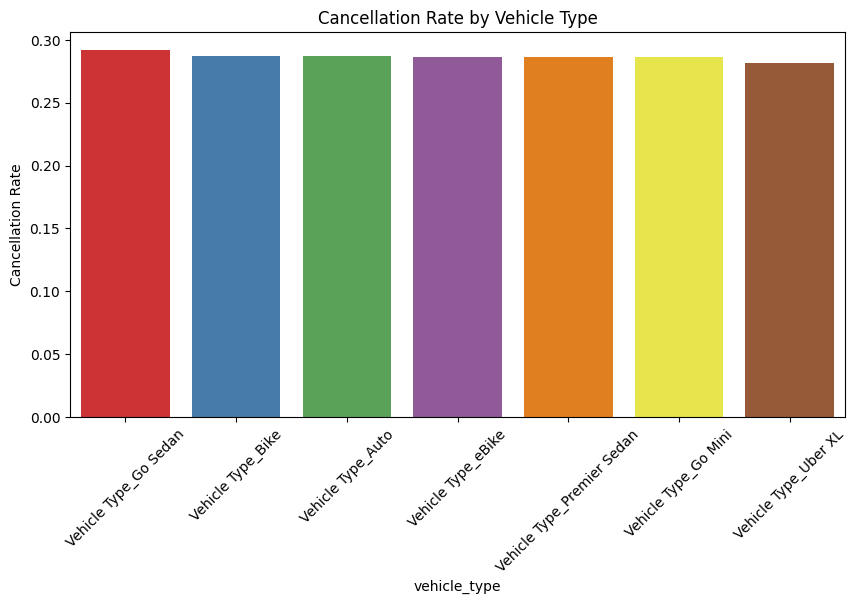

In [79]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=vehicle_cancel_rate.index,
    y=vehicle_cancel_rate.values,
    hue=vehicle_cancel_rate.index,
    palette='Set1',
    dodge=False
)
plt.xticks(rotation=45)
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Vehicle Type')
plt.show()

In [80]:
payment_cols = [col for col in df.columns if 'Payment Method' in col]

df_payment = df.melt(id_vars='target', value_vars=payment_cols,
                     var_name='payment_method', value_name='is_method')
df_payment = df_payment[df_payment['is_method'] == 1]

payment_cancel_rate = df_payment.groupby('payment_method')['target'].mean().sort_values(ascending=False)
print(payment_cancel_rate)

payment_method
Payment Method_UPI            0.472685
Payment Method_Cash           0.000000
Payment Method_Credit Card    0.000000
Payment Method_Debit Card     0.000000
Payment Method_Uber Wallet    0.000000
Name: target, dtype: float64


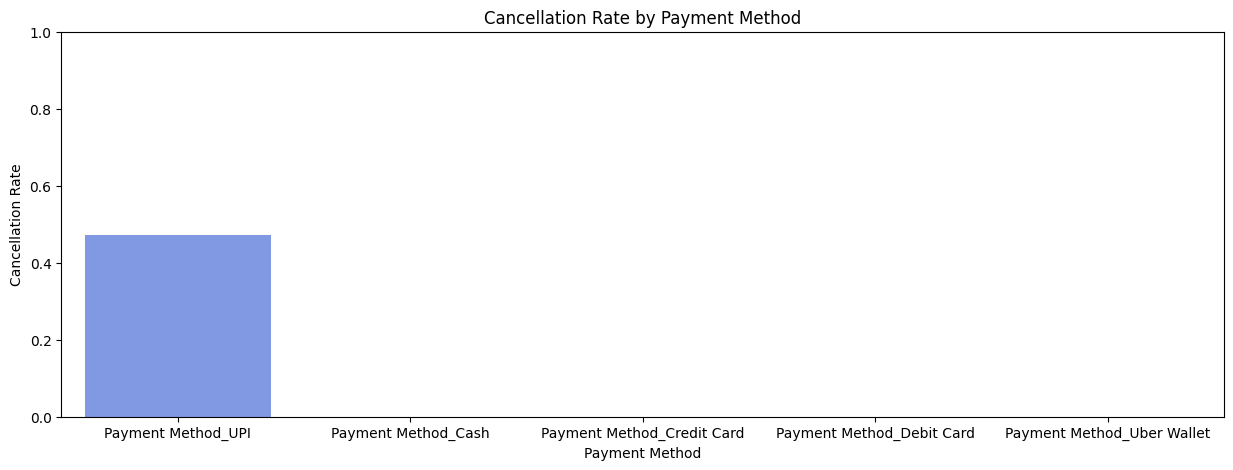

In [86]:
plt.figure(figsize=(15,5))
sns.barplot(
    x=payment_cancel_rate.index,
    y=payment_cancel_rate.values,
    hue=payment_cancel_rate.index,
    palette='coolwarm',
    dodge=False
)
plt.title('Cancellation Rate by Payment Method')
plt.ylabel('Cancellation Rate')
plt.xlabel('Payment Method')
plt.ylim(0,1)
plt.show()

### Summary
- Explored cancellations by **hour, 15-min intervals, day of month, day of week, weekday vs weekend**.
- Analyzed **vehicle type** and **payment method** using one-hot encoded features.
- Identified patterns and trends:
  - Peak cancellation times during the day.
  - Specific days of the month or week with higher cancellations.
  - Vehicle types and payment methods associated with higher cancellation rates.

  **Conclusion:**  
This notebook provides a comprehensive exploratory analysis and prepares the dataset for predictive modeling, highlighting critical factors affecting ride cancellations.